/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc


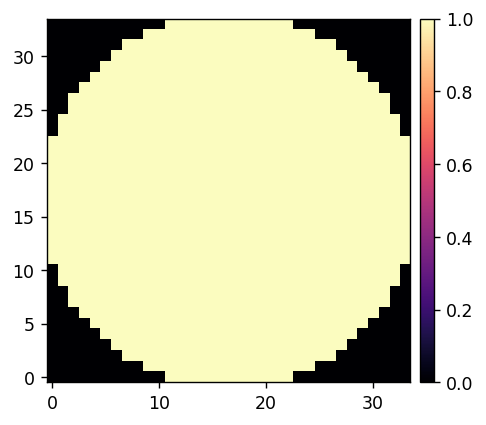

Exception in thread IndiTcpClientConnection-receiver:
Traceback (most recent call last):
  File "/opt/conda/envs/km310env/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/opt/conda/envs/km310env/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/opt/conda/envs/km310env/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 117, in _handle_inbound
    self._parser.parse(data)
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/parser.py", line 59, in parse
    self.parser.Parse(data)
  File "/home/conda/feedstock_root/build_artifacts/python-split_1710937908195/work/Modules/pyexpat.c", line 475, in EndElement
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/parser.py", line 174, in end_xml_element_handler
    element.set_from_text(contents)
  File "/opt/MagAOX/source/purepyind

In [27]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi

print(scoob_llowfsc.path)
data_path = scoob_llowfsc.path/'exp-data'

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])


In [ ]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_wfe_name = 'dm00disp01'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

camlo_ref_name = 'camlo_ref_0'
camlo_ref_offset_name = 'camlo_ref_offset'

camsci_rawims_path = Path(f'/opt/MagAOX/rawimages/{camsci_name}/')
camlo_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_name}/')
camlo_ref_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_name}/')
camlo_ref_offset_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_offset_name}/')
dm_wfe_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_wfe_name}/')
dm_lo_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_lo_name}/')
dm_ho_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_ho_name}/')

In [37]:
reload(scoobi)
xc, yc = (3900, 2575)
npsf = 256
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camsci_name, bin_mode=2)
scoobi.set_cam_exp_time(0.001, client0, cam_name=camsci_name,)
scoobi.set_cam_gain(120, client0, cam_name=camsci_name,)
scoobi.set_cam_blacklevel(2, client0, cam_name=camsci_name,)

Set camlo ROI.
Set the camlo exposure time to 1.00e-03s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 2.0


In [33]:
xc, yc = (5450, 1100) # 1005, 1125
npsf = 512
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camlo_name, bin_mode=2)
scoobi.set_cam_exp_time(0.1, client0, cam_name=camlo_name,)
scoobi.set_cam_gain(120, client0, cam_name=camlo_name,)
scoobi.set_cam_blacklevel(1, client0, cam_name=camlo_name,)

Set camsci ROI.
Set the camsci exposure time to 1.00e-01s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 1.0


In [38]:
camsci_stream = ImageStream(camsci_name)
camlo_stream = ImageStream(camlo_name)
dm_wfe_stream = ImageStream(dm_wfe_name)
dm_lo_stream = ImageStream(dm_lo_name)
dm_ho_stream = ImageStream(dm_ho_name)

In [36]:
camlo_dims = camlo_stream.shape[:-1]
print(camlo_dims)

scoobi.create_shmim(camlo_ref_name, camlo_dims)
scoobi.create_shmim(camlo_ref_offset_name, camlo_dims)

camlo_ref_stream = ImageStream(camlo_ref_name)
camlo_ref_offset_stream = ImageStream(camlo_ref_offset_name)

(512, 512)


In [39]:
# date = 20250409
date = today
exp_path = data_path/f'exp-{date}'
telem_data_path = data_path/f'exp-{date}'/'raw-telem'
unpacked_data_path = data_path/f'exp-{date}'/'unpacked-telem'

In [40]:
telem.make_dir(exp_path)
telem.make_dir(telem_data_path)
telem.make_dir(unpacked_data_path)

Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/raw-telem' already exists.
Directory '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem' already exists.


In [41]:
reload(telem)
telem.delete_files(camsci_rawims_path/'*.xrif')
telem.delete_files(camlo_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_offset_rawims_path/'*.xrif')
telem.delete_files(dm_wfe_rawims_path/'*.xrif')
telem.delete_files(dm_lo_rawims_path/'*.xrif')
telem.delete_files(dm_ho_rawims_path/'*.xrif')

telem.delete_files(telem_data_path/'*')
telem.delete_files(unpacked_data_path/'*')

In [42]:
telem.toggle(1, camsci_name, client0)
telem.toggle(1, camlo_name, client0)
telem.toggle(1, camlo_ref_name, client0)
telem.toggle(1, camlo_ref_offset_name, client0)
telem.toggle(1, dm_lo_name, client0)
telem.toggle(1, dm_ho_name, client0)

In [43]:
f_command = ensure_np_array(dm.make_f())
ring_command = ensure_np_array(dm.make_ring(rad=10))

for i in range(50):
    # camlo_ref_stream.write( np.random.randn(camlo_dims[0], camlo_dims[1]) )
    # camlo_ref_offset_stream.write( np.random.randn(camlo_dims[0], camlo_dims[1]) )
    camlo_ref_stream.write( i * np.ones(camlo_dims) )
    camlo_ref_offset_stream.write( -i * np.ones(camlo_dims) )
    dm_lo_stream.write(i*f_command)
    dm_ho_stream.write(i*ring_command)
    time.sleep(0.1)

camlo_ref_stream.write(np.zeros(camlo_dims))
camlo_ref_offset_stream.write(np.zeros(camlo_dims))
dm_lo_stream.write(np.zeros((34,34)))
dm_ho_stream.write(np.zeros((34,34)))


In [44]:
telem.toggle(0, camsci_name, client0)
telem.toggle(0, camlo_name, client0)
telem.toggle(0, camlo_ref_name, client0)
telem.toggle(0, camlo_ref_offset_name, client0)
telem.toggle(0, dm_lo_name, client0)
telem.toggle(0, dm_ho_name, client0)

In [61]:
telem.move_files(camsci_rawims_path, telem_data_path)
telem.move_files(camlo_rawims_path, telem_data_path)
telem.move_files(camlo_ref_rawims_path, telem_data_path)
telem.move_files(camlo_ref_offset_rawims_path, telem_data_path)
telem.move_files(dm_lo_rawims_path, telem_data_path)
telem.move_files(dm_ho_rawims_path, telem_data_path)

In [62]:
telem.unpack_data(telem_data_path, unpacked_data_path)

In [ ]:
camsci_fnames = telem.get_fnames(unpacked_data_path/f'{camsci_name}_*')
camlo_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_name}*')
camlo_ref_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_ref_name}*')
camlo_ref_offset_fnames = telem.get_fnames(unpacked_data_path/f'{camlo_ref_offset_name}*')
dm_lo_fnames = telem.get_fnames(unpacked_data_path/f'{dm_lo_name}*')
dm_ho_fnames = telem.get_fnames(unpacked_data_path/f'{dm_ho_name}*')

In [86]:
camsci_fnames[-200:]
# camlo_ref_fnames[:5], camlo_ref_offset_fnames[:5], dm_lo_fnames[:5], dm_ho_fnames[:5]

['/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215424987116653.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215424993929813.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425000777375.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425007527638.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425014487736.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425021406572.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-telem/camlo_20250410215425028240186.fits',
 '/home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250410/unpacked-tel

In [60]:
camlo_ref_stream.write(20*np.random.randn(camlo_dims[0], camlo_dims[1]))

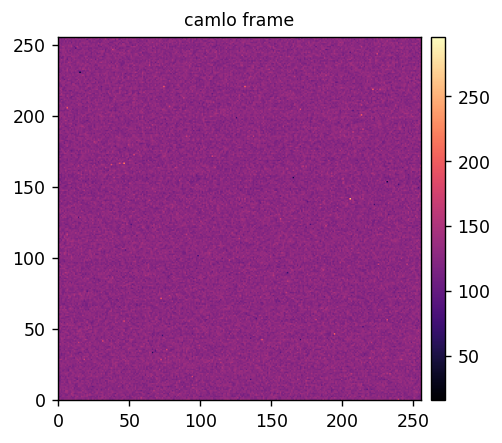

In [83]:
absolute = 0
camsci_data, camsci_times = telem.read_telem_data(camsci_fnames[:1700], absolute=absolute)
utils.imshow(
    [camsci_data[-1]],
    titles=[f'{camsci_name} frame'],
)

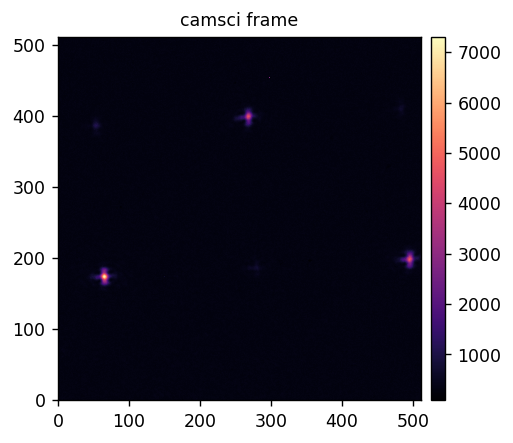

In [ ]:
camlo_data, camlo_times = telem.read_telem_data(camlo_fnames, absolute=absolute)
utils.imshow(
    [camlo_data[4]],
    titles=[f'{camlo_name} frame'],
)

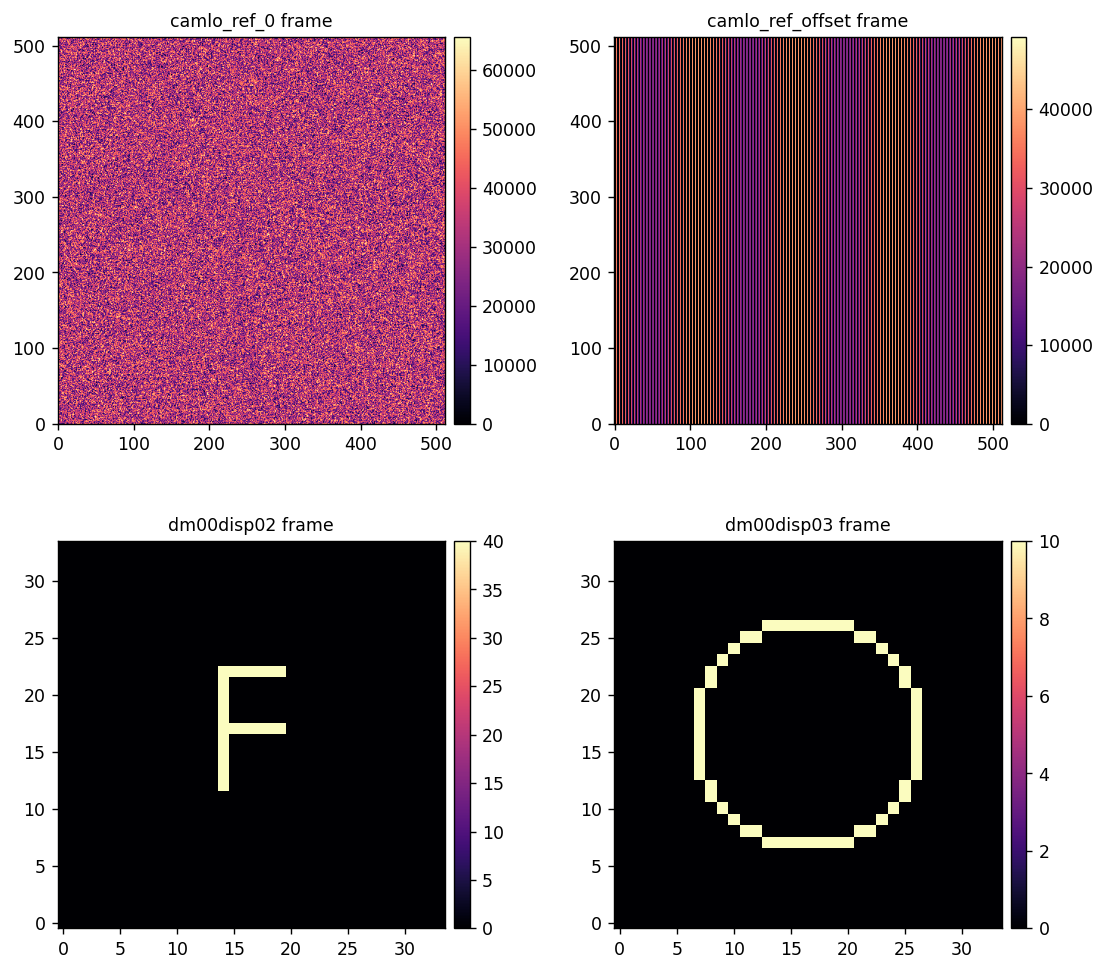

In [65]:
absolute = 0
# camsci_data, camsci_times = telem.read_telem_data(camsci_fnames, absolute=absolute)
# camlo_data, camlo_times = telem.read_telem_data(camlo_fnames, absolute=absolute)
camlo_ref_data, camlo_ref_times = telem.read_telem_data(camlo_ref_fnames, absolute=absolute)
camlo_ref_offset_data, camlo_ref_offset_times = telem.read_telem_data(camlo_ref_offset_fnames, absolute=absolute)
dm_lo_data, dm_lo_times = telem.read_telem_data(dm_lo_fnames, absolute=absolute)
dm_ho_data, dm_ho_times = telem.read_telem_data(dm_ho_fnames, absolute=absolute)

utils.imshow(
    [camlo_ref_data[-1], camlo_ref_offset_data[5], 
     dm_lo_data[40], dm_ho_data[10]],
    titles=[f'{camlo_ref_name} frame',
            f'{camlo_ref_offset_name} frame',
            f'{dm_lo_name} frame',
            f'{dm_ho_name} frame'],
    figsize=(10,10),
    Nrows=2, Ncols=2,
    wspace=0.35, 
    hspace=0.1,
)

In [26]:
np.min(camlo_ref_data[4])

np.uint16(0)

In [ ]:
camlo_ref_data

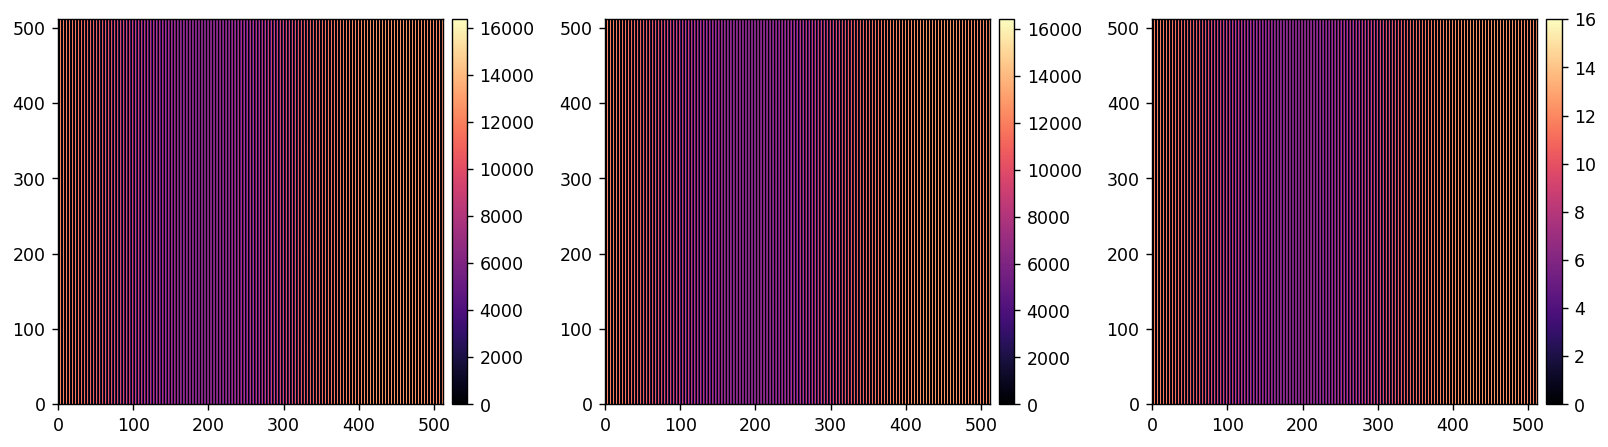

In [52]:
utils.imshow(
    [camlo_ref_data[0], camlo_ref_data[20], camlo_ref_data[20]-camlo_ref_data[10]],
)

Text(0.5, 1.0, 'dm00disp03 Times')

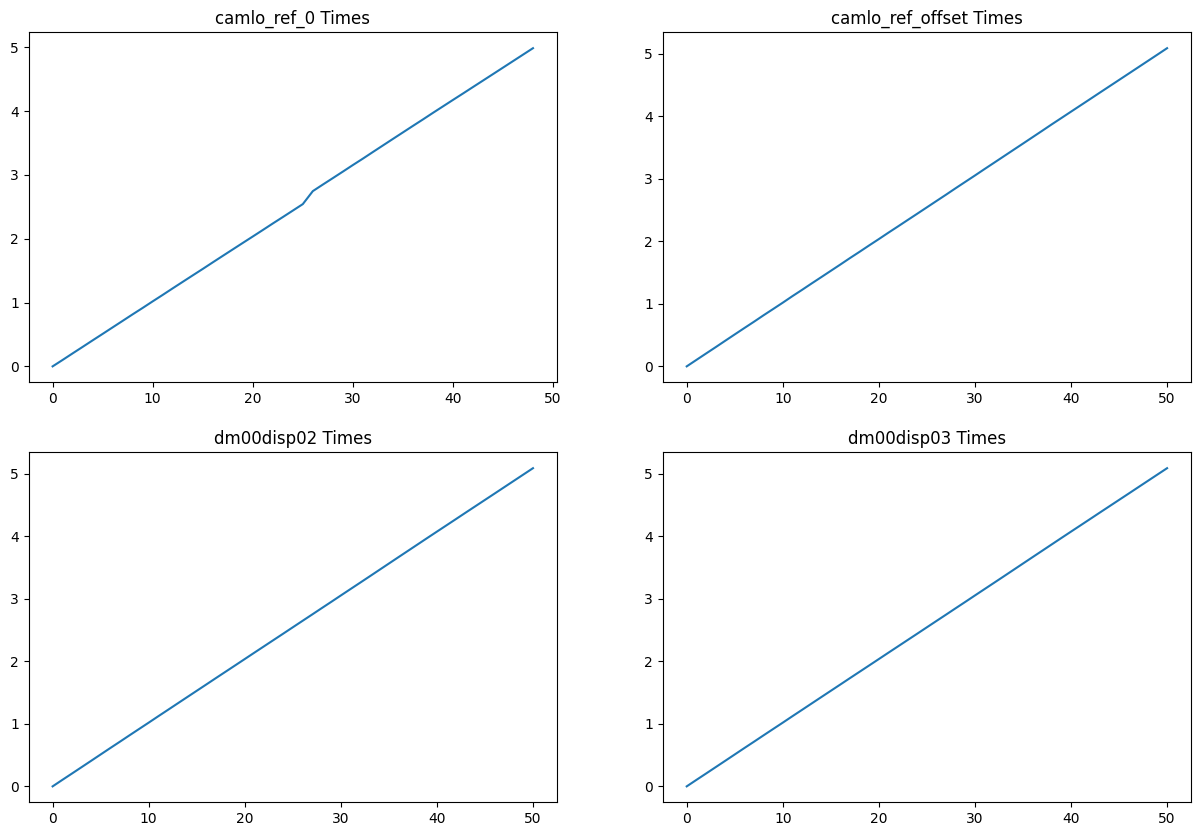

In [51]:
fig = plt.figure(figsize=(15,10))
plt.subplot(221)
plt.plot(camlo_ref_times)
plt.title(f'{camlo_ref_name} Times')

plt.subplot(222)
plt.plot(camlo_ref_offset_times)
plt.title(f'{camlo_ref_offset_name} Times')

plt.subplot(223)
plt.plot(dm_lo_times)
plt.title(f'{dm_lo_name} Times')

plt.subplot(224)
plt.plot(dm_ho_times)
plt.title(f'{dm_ho_name} Times')


In [104]:
telem.delete_files(telem_data_path/'*')
telem.delete_files(unpacked_data_path/'*')

# Random testing

In [36]:
reload(telem)
telem.toggle(1, 'camsci', client0)
time.sleep(1)
telem.toggle(0, 'camsci', client0)

In [37]:
# telem.move_files(camlo_path, telem_data_path)
telem.move_files(camsci_path, telem_data_path)

In [38]:
telem.unpack_data(telem_data_path, unpacked_data_path)

In [23]:
telem.delete_files(unpacked_data_path)

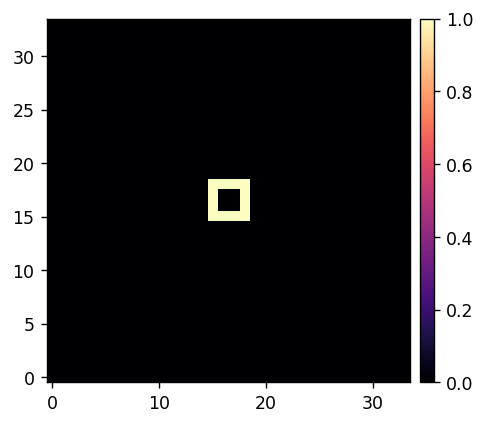

In [42]:
dm_command = ensure_np_array(dm.make_ring(rad=2))
utils.imshow([dm_command])

# Test DM shmimWriter

In [64]:
reload(telem)
dm_channel = 'dm00disp02'
telem.toggle(1, dm_channel, client0)

for i in range(10):
    time.sleep(1)
    dm02_stream.write( 0.010 * ensure_np_array(dm.make_ring(rad=2+i)) )

time.sleep(1)
dm02_stream.write( np.zeros((34,34)) )

telem.toggle(0, dm_channel, client0)

In [65]:
# telem.move_files(camlo_path, telem_data_path)
telem.move_files(dm02_path, telem_data_path)

In [ ]:
telem.unpack_data(telem_data_path, unpacked_data_path)


# Test loading the data in

In [8]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm01_name = 'dm00disp01'
dm02_name = 'dm00disp02'


In [9]:
camsci_fnames = telem.get_fnames(unpacked_data_path/f'{camsci_name}*')
dm01_fnames = telem.get_fnames(unpacked_data_path/f'{dm01_name}*')
dm02_fnames = telem.get_fnames(unpacked_data_path/f'{dm02_name}*')

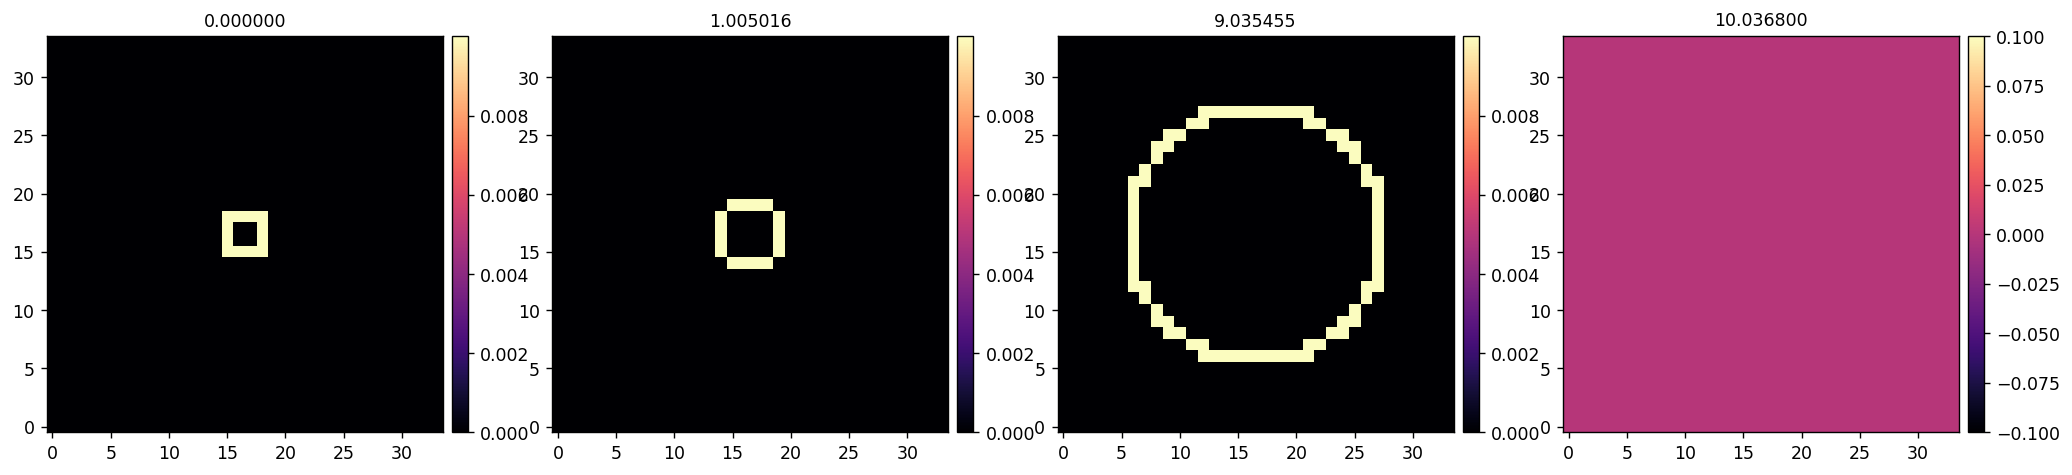

In [11]:
reload(telem)
dm01_data, dm01_times = telem.read_telem_data(dm01_fnames, absolute=False)

utils.imshow(
    [dm01_data[0], dm01_data[1], dm01_data[-2], dm01_data[-1]],
    titles=[f'{dm01_times[0]:.6f}',
            f'{dm01_times[1]:.6f}',
            f'{dm01_times[-2]:.6f}',
            f'{dm01_times[-1]:.6f}'],
    figsize=(20,5),
)

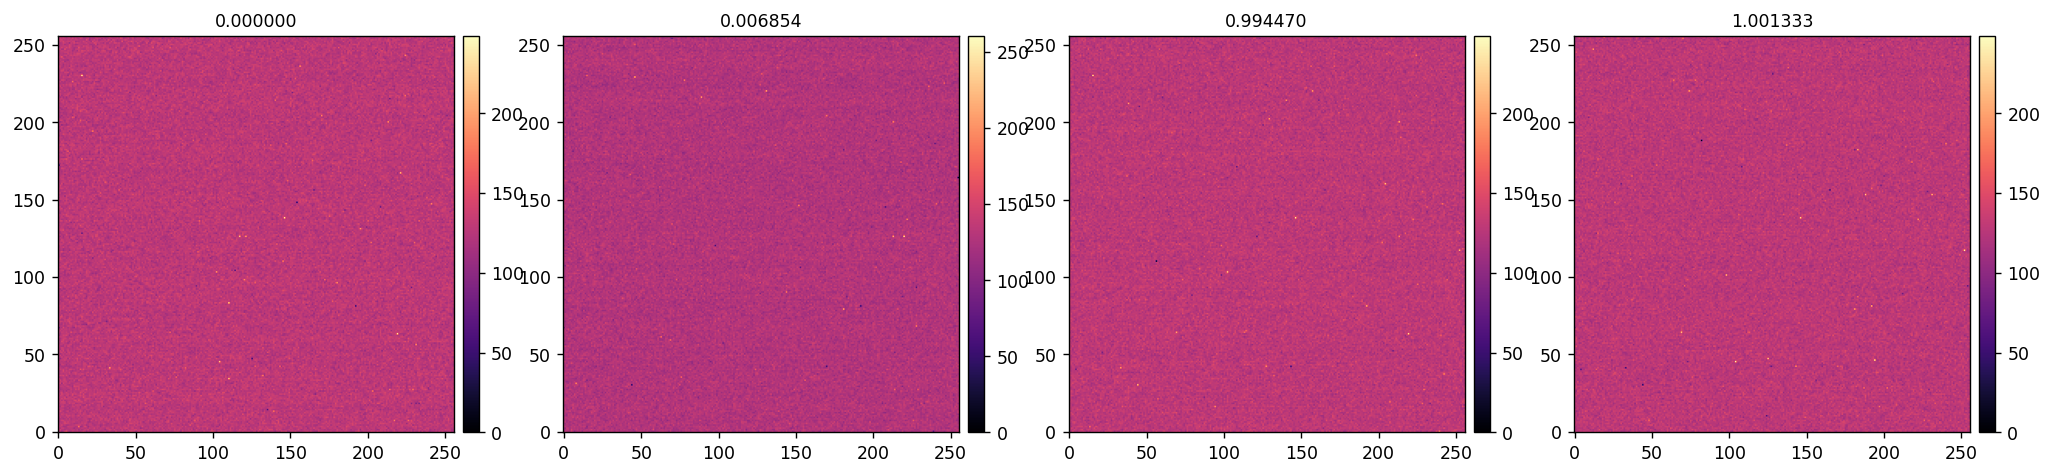

Text(0.5, 1.0, 'Mean FPS = 145.806')

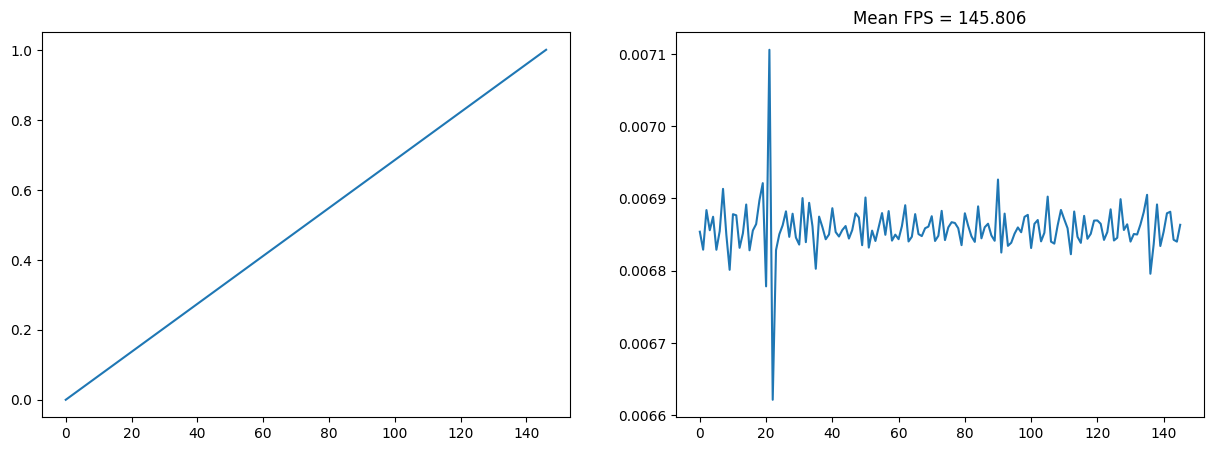

In [22]:
camsci_data, camsci_times = telem.read_telem_data(camsci_fnames, absolute=False)

utils.imshow(
    [camsci_data[0], camsci_data[1], camsci_data[-2], camsci_data[-1]],
    titles=[f'{camsci_times[0]:.6f}',
            f'{camsci_times[1]:.6f}',
            f'{camsci_times[-2]:.6f}',
            f'{camsci_times[-1]:.6f}'],
    figsize=(20,5),
)

camsci_delTs = camsci_times[1:] - camsci_times[:-1]
mean_delT = np.mean(camsci_delTs)
mean_fps = 1/mean_delT

fig = plt.figure(figsize=(15,5))
plt.subplot(121)
plt.plot(camsci_times)

plt.subplot(122)
plt.plot(camsci_delTs)
plt.title(f'Mean FPS = {mean_fps:.3f}')
